# Modelagem de Sobrevida - LUSC

## Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index
from sksurv.util import Surv
from sklearn.impute import SimpleImputer
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from scipy.stats import t 
from itertools import product

## Settings

In [2]:
try:
    import torch
    import torchtuples as tt

    from pycox.models import CoxPH, DeepHitSingle
    from pycox.evaluation import EvalSurv

    deep_ok = True

except Exception as e:
    deep_ok = False
    print(e)

In [3]:
cohort = "LUSC"

project_dir = Path("..").resolve()

data_path = project_dir / "data" / "processed" / "lusc" / "lusc_integrated_full.csv"

results_dir = project_dir / "reports" / "results" / "lusc"
figures_dir = project_dir / "reports" / "figures" / "lusc"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42
n_splits = 5

In [4]:
print(data_path)

df = pd.read_csv(data_path, sep=";")

print("Shape:", df.shape)
df.head()

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\data\processed\lusc\lusc_integrated_full.csv
Shape: (494, 20576)


,patient_id,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,...,0.8379,1.3645,5.4173,6.8770,8.6783,10.8793,7.2645,10.5071,6.8770,10.8624
1,TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,...,0.5614,0.0000,3.7408,2.9374,8.6306,12.4955,8.0396,10.7039,6.9061,10.5319
2,TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,...,1.1286,0.0000,4.9101,3.4705,8.9517,11.5836,6.8141,10.7232,6.9587,10.6149
3,TCGA-18-3409,3747.0,0,74.0,20.0,3.0,0,0,0,1,...,1.6094,2.4894,4.8166,1.0183,9.5472,13.0532,8.3195,10.3556,6.7297,10.0400
4,TCGA-18-3410,146.0,1,81.0,0.0,3.0,0,1,0,1,...,0.8382,0.4791,5.0053,4.2569,10.0043,9.9764,7.1216,9.9741,5.9462,10.4818


In [5]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

In [6]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(30)

Total de nulos: 69


clin__radiation_therapy_bin                   68
clin__history_of_neoadjuvant_treatment_bin     1
dtype: int64

In [7]:
df[event_col] = df[event_col].astype(int)
df[time_col] = df[time_col].astype(float)

print(df[event_col].value_counts())

print( round(df[event_col].mean() * 100, 2), "%")

print("Mínimo:", df[time_col].min())
print("Mediana:", df[time_col].median())
print("Máximo:", df[time_col].max())

surv__OS
0    282
1    212
Name: count, dtype: int64
42.91 %
Mínimo: 1.0
Mediana: 663.0
Máximo: 5287.0


In [8]:
# Assinatura imune 10 genes
genes_lusc_10 = [
    "CALCB", "GCGR", "HTR3A", "AMH", "VGF",
    "SEMA3B", "NRTN", "ENG", "ACVRL1", "NR4A1"
]

# Assinatura imune 13 genes
genes_lusc_13 = [
    "FGF4", "FGL1", "LIM2", "NPY", "F13A1",
    "CDH12", "CD1E", "OTX2", "ADRA1D",
    "SAMD9L", "ZFP42", "GAGE2A", "KLRC2"
]

# Assinatura glicolítica 3 genes
genes_lusc_glicolise = [
    "HKDC1", "ALDH7A1", "MDH1"
]

# Assinatura prognóstica NSCLC
genes_nsclc = [
    "ABCC4", "CCL19", "SLC39A8", "CD27",
    "FUT7", "DAG1", "ZNF71"
]

# Drivers clássicos de LUSC
genes_lusc_drivers = [
    "TP53", "CDKN2A", "PTEN", "PIK3CA", "KEAP1",
    "NFE2L2", "NOTCH1", "RB1", "SOX2", "TP63", "FGFR1"
]

genes_literatura = (
    genes_lusc_10
    + genes_lusc_13
    + genes_lusc_glicolise
    + genes_nsclc
    + genes_lusc_drivers
)

genes_literatura = list(dict.fromkeys(genes_literatura))

genes_candidatos = [g for g in genes_literatura if g in df.columns]
genes_ausentes = [g for g in genes_literatura if g not in df.columns]

clin_cols = [
    c for c in df.columns
    if c.startswith("clin__")
    and c not in [time_col, event_col]
    and "vital_status" not in c.lower()
]


In [9]:
feature_cols = clin_cols + genes_candidatos
feature_cols = list(dict.fromkeys(feature_cols))

X = df[feature_cols].copy()
tempo = df[time_col].copy()
evento = df[event_col].copy()

print("Colunas clínicas:", len(clin_cols))
print("Genes candidatos presentes:", len(genes_candidatos))
print(genes_candidatos)
print("Genes candidatos ausentes:", len(genes_ausentes))
print(genes_ausentes)
print("Total de features antes da seleção por fold:", X.shape[1])

Colunas clínicas: 43
Genes candidatos presentes: 44
['CALCB', 'GCGR', 'HTR3A', 'AMH', 'VGF', 'SEMA3B', 'NRTN', 'ENG', 'ACVRL1', 'NR4A1', 'FGF4', 'FGL1', 'LIM2', 'NPY', 'F13A1', 'CDH12', 'CD1E', 'OTX2', 'ADRA1D', 'SAMD9L', 'ZFP42', 'GAGE2A', 'KLRC2', 'HKDC1', 'ALDH7A1', 'MDH1', 'ABCC4', 'CCL19', 'SLC39A8', 'CD27', 'FUT7', 'DAG1', 'ZNF71', 'TP53', 'CDKN2A', 'PTEN', 'PIK3CA', 'KEAP1', 'NFE2L2', 'NOTCH1', 'RB1', 'SOX2', 'TP63', 'FGFR1']
Genes candidatos ausentes: 0
[]
Total de features antes da seleção por fold: 87


In [10]:
mask_valid_survival = (
    tempo.notna()
    & evento.notna()
    & np.isfinite(tempo)
    & (tempo > 0)
)

X = X.loc[mask_valid_survival].copy()
tempo = tempo.loc[mask_valid_survival].astype(float).copy()
evento = evento.loc[mask_valid_survival].astype(int).copy()

In [11]:
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

folds = list(skf.split(X, evento))

print(len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        "| teste =", len(test_idx),
        "| eventos teste =", int(evento.iloc[test_idx].sum())
    )

5
Fold 1: treino = 395 | teste = 99 | eventos teste = 43
Fold 2: treino = 395 | teste = 99 | eventos teste = 43
Fold 3: treino = 395 | teste = 99 | eventos teste = 42
Fold 4: treino = 395 | teste = 99 | eventos teste = 42
Fold 5: treino = 396 | teste = 98 | eventos teste = 42


## Pré-processamento nos folds

In [12]:
def tirar_baixa_variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas = X_train.columns[seletor.get_support()]

    X_train_sel = pd.DataFrame(X_train_sel, columns=colunas, index=X_train.index)
    X_test_sel = pd.DataFrame(X_test_sel, columns=colunas, index=X_test.index)

    return X_train_sel, X_test_sel

In [13]:
def tirar_colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()

    matriz_superior = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [14]:
def padronizar_dados(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        X_test_scaled,
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_scaled, X_test_scaled

In [15]:
def preparar_fold(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    X_train_prep, X_test_prep = tirar_baixa_variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    X_train_prep, X_test_prep, removidas_corr = tirar_colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    if usar_scaler:
        X_train_prep, X_test_prep = padronizar_dados(
            X_train_prep,
            X_test_prep
        )

    return X_train_prep, X_test_prep, removidas_corr

In [16]:
def criar_y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [17]:
def selecionar_genes_cox_univariado_fold(
    X_train,
    tempo_train,
    evento_train,
    genes_candidatos,
    p_limite=0.05
):
    linhas = []

    for gene in genes_candidatos:
        if gene not in X_train.columns:
            continue

        tmp = pd.DataFrame({
            "tempo": tempo_train.values,
            "evento": evento_train.values,
            gene: X_train[gene].values
        }).dropna()

        if tmp.shape[0] < 20:
            continue

        if tmp[gene].nunique() < 2:
            continue

        desvio = tmp[gene].std()
        if desvio == 0 or pd.isna(desvio):
            continue

        tmp[gene] = (tmp[gene] - tmp[gene].mean()) / desvio

        try:
            cph_uni = CoxPHFitter()
            cph_uni.fit(tmp, duration_col="tempo", event_col="evento")
            s = cph_uni.summary.loc[gene]

            linhas.append({
                "gene": gene,
                "coef": s["coef"],
                "HR": s["exp(coef)"],
                "p": s["p"]
            })

        except Exception:
            continue

    tabela = pd.DataFrame(linhas)

    if tabela.empty:
        return [], tabela

    tabela = tabela.sort_values("p").reset_index(drop=True)
    genes_fold = tabela.loc[tabela["p"] < p_limite, "gene"].tolist()

    return genes_fold, tabela


def aplicar_selecao_genes_no_fold(
    X_train,
    X_test,
    tempo_train,
    evento_train,
    clin_cols,
    genes_candidatos,
    p_limite=0.05,
    verbose=True
):
    genes_fold, tabela_genes_fold = selecionar_genes_cox_univariado_fold(
        X_train=X_train,
        tempo_train=tempo_train,
        evento_train=evento_train,
        genes_candidatos=genes_candidatos,
        p_limite=p_limite
    )

    cols_clinicas = [c for c in clin_cols if c in X_train.columns]
    cols_fold = cols_clinicas + genes_fold
    cols_fold = list(dict.fromkeys(cols_fold))

    if verbose:
        print("Genes selecionados neste fold:", len(genes_fold), genes_fold)

    return X_train[cols_fold].copy(), X_test[cols_fold].copy(), genes_fold, tabela_genes_fold


In [18]:
resultados_folds = []
resumo_modelos = []
tuning_nested = []

def guardar_resultado(modelo, fold, c_train, c_test, genes_fold=None, hiperparametros=""):
    if genes_fold is None:
        genes_fold = []

    resultados_folds.append({
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test,
        "n_genes_fold": len(genes_fold),
        "genes_fold": ", ".join(genes_fold),
        "hiperparametros_fold": hiperparametros
    })


def criar_resumo_modelo(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resumo = {
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resumo_modelos.append(resumo)

    return pd.DataFrame([resumo])

## Tuning aninhado dos hiperparâmetros

In [19]:
param_grid_cox = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_weibull = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_rsf = {
    "n_estimators": [100, 200],
    "min_samples_split": [15, 25],
    "min_samples_leaf": [10, 20],
    "max_features": ["sqrt", 5]
}

param_grid_gbsa = {
    "n_estimators": [100, 150],
    "learning_rate": [0.01, 0.02],
    "max_depth": [1, 2],
    "subsample": [0.7]
}

## Funções

In [20]:
def gerar_combinacoes_parametros(param_grid):
    chaves = list(param_grid.keys())
    valores = [param_grid[chave] for chave in chaves]

    combinacoes = []
    for item in product(*valores):
        combinacoes.append(dict(zip(chaves, item)))

    return combinacoes


def parametros_para_texto(params):
    return "; ".join([f"{chave}={valor}" for chave, valor in params.items()])


def ajustar_parametros_por_dimensao(params, n_features):
    params = params.copy()

    if "max_features" in params:
        valor = params["max_features"]
        if isinstance(valor, int) and valor > n_features:
            params["max_features"] = n_features

    return params

In [21]:
def calcular_score_validacao_modelo(
    nome_modelo,
    params,
    X_train_raw,
    X_val_raw,
    tempo_train,
    tempo_val,
    evento_train,
    evento_val,
    usar_scaler,
    var_threshold=0.01,
    corr_threshold=0.90
):
    try:
        X_train_sel, X_val_sel, genes_fold, _ = aplicar_selecao_genes_no_fold(
            X_train=X_train_raw,
            X_test=X_val_raw,
            tempo_train=tempo_train,
            evento_train=evento_train,
            clin_cols=clin_cols,
            genes_candidatos=genes_candidatos,
            p_limite=0.05,
            verbose=False
        )

        X_train_prep, X_val_prep, _ = preparar_fold(
            X_train_sel,
            X_val_sel,
            usar_scaler=usar_scaler,
            var_threshold=var_threshold,
            corr_threshold=corr_threshold
        )

        if X_train_prep.shape[1] == 0:
            return np.nan, len(genes_fold)

        params_ajustados = ajustar_parametros_por_dimensao(
            params,
            n_features=X_train_prep.shape[1]
        )

        if nome_modelo == "CoxPH":
            df_train = X_train_prep.copy()
            df_train[time_col] = tempo_train.values
            df_train[event_col] = evento_train.values

            modelo = CoxPHFitter(**params_ajustados)
            modelo.fit(df_train, duration_col=time_col, event_col=event_col)

            risco_val = modelo.predict_partial_hazard(X_val_prep)
            c_val = concordance_index(tempo_val, -risco_val, evento_val)

        elif nome_modelo == "Weibull AFT":
            df_train = X_train_prep.copy()
            df_train[time_col] = tempo_train.values
            df_train[event_col] = evento_train.values

            modelo = WeibullAFTFitter(**params_ajustados)
            modelo.fit(df_train, duration_col=time_col, event_col=event_col)

            pred_val = modelo.predict_median(X_val_prep)
            pred_val = pred_val.replace([np.inf, -np.inf], np.nan)
            pred_val = pred_val.fillna(pred_val.max())

            c_val = concordance_index(tempo_val, pred_val, evento_val)

        elif nome_modelo == "RSF":
            y_train = criar_y_sksurv(tempo_train, evento_train)

            modelo = RandomSurvivalForest(
                **params_ajustados,
                n_jobs=-1,
                random_state=seed
            )
            modelo.fit(X_train_prep, y_train)

            risco_val = modelo.predict(X_val_prep)
            c_val = concordance_index_censored(
                evento_val.astype(bool),
                tempo_val,
                risco_val
            )[0]

        elif nome_modelo == "GBSA":
            y_train = criar_y_sksurv(tempo_train, evento_train)

            modelo = GradientBoostingSurvivalAnalysis(
                **params_ajustados,
                random_state=seed
            )
            modelo.fit(X_train_prep, y_train)

            risco_val = modelo.predict(X_val_prep)
            c_val = concordance_index_censored(
                evento_val.astype(bool),
                tempo_val, 
                risco_val
            )[0]

        else:
            raise ValueError("Tem modelo não configurado")
        return c_val, len(genes_fold)

    except Exception as erro:
        return np.nan, np.nan

In [22]:
def escolher_hiperparametros_no_treino_externo(
    nome_modelo,
    param_grid,
    X_outer_train,
    tempo_outer_train,
    evento_outer_train,
    usar_scaler,
    fold_externo,
    n_splits_inner=3
):
    inner_cv = StratifiedKFold(
        n_splits=n_splits_inner,
        shuffle=True,
        random_state=seed + fold_externo
    )

    linhas_tuning = []
    combinacoes = gerar_combinacoes_parametros(param_grid)

    for params in combinacoes:
        scores = []
        genes_quantidades = []

        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(
            inner_cv.split(X_outer_train, evento_outer_train),
            start=1
        ):
            X_inner_train = X_outer_train.iloc[inner_train_idx].copy()
            X_inner_val = X_outer_train.iloc[inner_val_idx].copy()

            tempo_inner_train = tempo_outer_train.iloc[inner_train_idx]
            tempo_inner_val = tempo_outer_train.iloc[inner_val_idx]

            evento_inner_train = evento_outer_train.iloc[inner_train_idx]
            evento_inner_val = evento_outer_train.iloc[inner_val_idx]

            c_val, n_genes = calcular_score_validacao_modelo(
                nome_modelo=nome_modelo,
                params=params,
                X_train_raw=X_inner_train,
                X_val_raw=X_inner_val,
                tempo_train=tempo_inner_train,
                tempo_val=tempo_inner_val,
                evento_train=evento_inner_train,
                evento_val=evento_inner_val,
                usar_scaler=usar_scaler
            )

            scores.append(c_val)
            genes_quantidades.append(n_genes)

            linhas_tuning.append({
                "modelo": nome_modelo,
                "fold_externo": fold_externo,
                "fold_interno": inner_fold,
                "parametros": parametros_para_texto(params),
                "c_index_validacao_interna": c_val,
                "n_genes_inner": n_genes
            })

    tabela_tuning = pd.DataFrame(linhas_tuning)

    resumo_parametros = (
        tabela_tuning
        .groupby(["modelo", "fold_externo", "parametros"], as_index=False)
        .agg(
            c_index_validacao_interna_medio=("c_index_validacao_interna", "mean"),
            c_index_validacao_interna_dp=("c_index_validacao_interna", "std"),
            n_genes_inner_medio=("n_genes_inner", "mean")
        )
        .sort_values("c_index_validacao_interna_medio", ascending=False)
    )

    melhor_texto = resumo_parametros.iloc[0]["parametros"]
    melhor_params = None

    for params in combinacoes:
        if parametros_para_texto(params) == melhor_texto:
            melhor_params = params
            break

    tuning_nested.extend(linhas_tuning)

    return melhor_params, resumo_parametros

In [23]:
def treinar_e_avaliar_modelo_final(
    nome_modelo,
    params,
    X_train_raw,
    X_test_raw,
    tempo_train,
    tempo_test,
    evento_train,
    evento_test,
    usar_scaler,
    genes_fold,
    fold
):
    X_train_prep, X_test_prep, _ = preparar_fold(
        X_train_raw,
        X_test_raw,
        usar_scaler=usar_scaler,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    X_train_prep = X_train_prep.copy()
    X_test_prep = X_test_prep.copy()

    X_test_prep = X_test_prep.reindex(columns=X_train_prep.columns)

    X_train_prep = X_train_prep.apply(pd.to_numeric, errors="coerce")
    X_test_prep = X_test_prep.apply(pd.to_numeric, errors="coerce")

    X_train_prep = X_train_prep.replace([np.inf, -np.inf], np.nan)
    X_test_prep = X_test_prep.replace([np.inf, -np.inf], np.nan)

    colunas_validas = X_train_prep.columns[X_train_prep.notna().any()]

    X_train_prep = X_train_prep[colunas_validas]
    X_test_prep = X_test_prep[colunas_validas]

    if X_train_prep.shape[1] == 0:
        raise ValueError(
            "Nenhuma variável válida"
        )

    imputer = SimpleImputer(strategy="median")

    X_train_prep = pd.DataFrame(
        imputer.fit_transform(X_train_prep),
        columns=colunas_validas,
        index=X_train_prep.index
    )

    X_test_prep = pd.DataFrame(
        imputer.transform(X_test_prep),
        columns=colunas_validas,
        index=X_test_prep.index
    )

    tempo_train = pd.Series(
        np.asarray(tempo_train).ravel(),
        index=X_train_prep.index
    )

    tempo_test = pd.Series(
        np.asarray(tempo_test).ravel(),
        index=X_test_prep.index
    )

    evento_train = pd.Series(
        np.asarray(evento_train).ravel(),
        index=X_train_prep.index
    )

    evento_test = pd.Series(
        np.asarray(evento_test).ravel(),
        index=X_test_prep.index
    )

    mask_train = (
        tempo_train.notna()
        & evento_train.notna()
        & (tempo_train > 0)
    )

    mask_test = (
        tempo_test.notna()
        & evento_test.notna()
        & (tempo_test > 0)
    )

    X_train_prep = X_train_prep.loc[mask_train]
    tempo_train = tempo_train.loc[mask_train]
    evento_train = evento_train.loc[mask_train]

    X_test_prep = X_test_prep.loc[mask_test]
    tempo_test = tempo_test.loc[mask_test]
    evento_test = evento_test.loc[mask_test]

    evento_train = evento_train.astype(int)
    evento_test = evento_test.astype(int)

    params_ajustados = ajustar_parametros_por_dimensao(
        params,
        n_features=X_train_prep.shape[1]
    )

    if nome_modelo == "CoxPH":
        df_train = X_train_prep.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = CoxPHFitter(**params_ajustados)
        modelo.fit(
            df_train,
            duration_col=time_col,
            event_col=event_col
        )

        risco_train = modelo.predict_partial_hazard(X_train_prep)
        risco_test = modelo.predict_partial_hazard(X_test_prep)

        c_train = concordance_index(
            tempo_train,
            -risco_train,
            evento_train
        )

        c_test = concordance_index(
            tempo_test,
            -risco_test,
            evento_test
        )

    elif nome_modelo == "Weibull AFT":
        df_train = X_train_prep.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = WeibullAFTFitter(**params_ajustados)
        modelo.fit(
            df_train,
            duration_col=time_col,
            event_col=event_col
        )

        pred_train = modelo.predict_median(X_train_prep)
        pred_test = modelo.predict_median(X_test_prep)

        pred_train = pred_train.replace([np.inf, -np.inf], np.nan)
        pred_test = pred_test.replace([np.inf, -np.inf], np.nan)

        pred_train = pred_train.fillna(pred_train.max())
        pred_test = pred_test.fillna(pred_test.max())

        c_train = concordance_index(
            tempo_train,
            pred_train,
            evento_train
        )

        c_test = concordance_index(
            tempo_test,
            pred_test,
            evento_test
        )

    elif nome_modelo == "RSF":
        y_train = criar_y_sksurv(tempo_train, evento_train)

        modelo = RandomSurvivalForest(
            **params_ajustados,
            n_jobs=-1,
            random_state=seed
        )

        modelo.fit(X_train_prep, y_train)

        risco_train = modelo.predict(X_train_prep)
        risco_test = modelo.predict(X_test_prep)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    elif nome_modelo == "GBSA":
        y_train = criar_y_sksurv(tempo_train, evento_train)

        modelo = GradientBoostingSurvivalAnalysis(
            **params_ajustados,
            random_state=seed
        )

        modelo.fit(X_train_prep, y_train)

        risco_train = modelo.predict(X_train_prep)
        risco_test = modelo.predict(X_test_prep)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    guardar_resultado(
        nome_modelo,
        fold,
        c_train,
        c_test,
        genes_fold=genes_fold,
        hiperparametros=parametros_para_texto(params_ajustados)
    )

    return c_train, c_test

In [24]:
def avaliar_modelo_com_nested_tuning(nome_modelo, param_grid, usar_scaler):
    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f" {nome_modelo} - fold externo {fold}")

        X_outer_train = X.iloc[train_idx].copy()
        X_outer_test = X.iloc[test_idx].copy()

        tempo_outer_train = tempo.iloc[train_idx]
        tempo_outer_test = tempo.iloc[test_idx]

        evento_outer_train = evento.iloc[train_idx]
        evento_outer_test = evento.iloc[test_idx]

        melhor_params, resumo_parametros = escolher_hiperparametros_no_treino_externo(
            nome_modelo=nome_modelo,
            param_grid=param_grid,
            X_outer_train=X_outer_train,
            tempo_outer_train=tempo_outer_train,
            evento_outer_train=evento_outer_train,
            usar_scaler=usar_scaler,
            fold_externo=fold,
            n_splits_inner=3
        )

        print("Melhores hiperparâmetros:", melhor_params)

        X_train_sel, X_test_sel, genes_fold, _ = aplicar_selecao_genes_no_fold(
            X_train=X_outer_train,
            X_test=X_outer_test,
            tempo_train=tempo_outer_train,
            evento_train=evento_outer_train,
            clin_cols=clin_cols,
            genes_candidatos=genes_candidatos,
            p_limite=0.05,
            verbose=True
        )

        c_train, c_test = treinar_e_avaliar_modelo_final(
            nome_modelo=nome_modelo,
            params=melhor_params,
            X_train_raw=X_train_sel,
            X_test_raw=X_test_sel,
            tempo_train=tempo_outer_train,
            tempo_test=tempo_outer_test,
            evento_train=evento_outer_train,
            evento_test=evento_outer_test,
            usar_scaler=usar_scaler,
            genes_fold=genes_fold,
            fold=fold
        )

        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))


## Modelo 1 - Cox Proportional Hazards

In [25]:
nome_modelo = "CoxPH"

avaliar_modelo_com_nested_tuning(
    nome_modelo=nome_modelo,
    param_grid=param_grid_cox,
    usar_scaler=True
)

 CoxPH - fold externo 1
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.7222
C-index teste: 0.5866
 CoxPH - fold externo 2
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.7
C-index teste: 0.6478
 CoxPH - fold externo 3
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
C-index treino: 0.7332
C-index teste: 0.4989
 CoxPH - fold externo 4
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 12 ['HKDC1', 'ALDH7A1', 'SEMA3B', 'MDH1', 'GCGR', 'FGF4', 'F13A1'

In [26]:
resumo_cox = criar_resumo_modelo("CoxPH")
resumo_cox

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.709633,0.614416,0.081458,0.095217


## Modelo 2 - Weibull AFT

In [27]:
nome_modelo = "Weibull AFT"

avaliar_modelo_com_nested_tuning(
    nome_modelo=nome_modelo,
    param_grid=param_grid_weibull,
    usar_scaler=True
)


 Weibull AFT - fold externo 1
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.7216
C-index teste: 0.5814
 Weibull AFT - fold externo 2
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.6998
C-index teste: 0.6437
 Weibull AFT - fold externo 3
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
C-index treino: 0.7346
C-index teste: 0.506
 Weibull AFT - fold externo 4
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 12 ['HKDC1', 'ALDH7A1', 'SEMA3B', 'MDH1

In [28]:
resumo_weibull = criar_resumo_modelo("Weibull AFT")
resumo_weibull

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,Weibull AFT,0.709771,0.612305,0.077549,0.097466


## Modelo 3 - Random Survival Forest

In [29]:
nome_modelo = "RSF"

avaliar_modelo_com_nested_tuning(
    nome_modelo=nome_modelo,
    param_grid=param_grid_rsf,
    usar_scaler=False
)


 RSF - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 5}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.8165
C-index teste: 0.5956
 RSF - fold externo 2
Melhores hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.8021
C-index teste: 0.5994
 RSF - fold externo 3
Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 25, 'min_samples_leaf': 20, 'max_features': 5}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CAL

In [30]:
resumo_rsf = criar_resumo_modelo("RSF")
resumo_rsf

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,RSF,0.806759,0.598792,0.064195,0.207968


## Modelo 4 - Gradient Boosting Survival Analysis

In [31]:
nome_modelo = "GBSA"

avaliar_modelo_com_nested_tuning(
    nome_modelo=nome_modelo,
    param_grid=param_grid_gbsa,
    usar_scaler=False
)


 GBSA - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 1, 'subsample': 0.7}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.6701
C-index teste: 0.5346
 GBSA - fold externo 2
Melhores hiperparâmetros: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 1, 'subsample': 0.7}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.6688
C-index teste: 0.5273
 GBSA - fold externo 3
Melhores hiperparâmetros: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 1, 'subsample': 0.7}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
C-index treino: 0.6582
C-index

In [32]:
resumo_gbsa = criar_resumo_modelo("GBSA")
resumo_gbsa

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,GBSA,0.665222,0.558546,0.063328,0.106676


## Modelo 5 - DeepSurv

In [33]:
def preparar_dados_deep(X_train, X_test):
    X_train_deep = X_train.astype("float32").values
    X_test_deep = X_test.astype("float32").values

    return X_train_deep, X_test_deep

In [34]:
nome_modelo = "DeepSurv"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32")
    tempo_test = tempo.iloc[test_idx].astype("float32")

    evento_train = evento.iloc[train_idx].astype("float32")
    evento_test = evento.iloc[test_idx].astype("float32")

    X_train, X_test, genes_fold, tabela_genes_fold = aplicar_selecao_genes_no_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        clin_cols=clin_cols,
        genes_candidatos=genes_candidatos,
        p_limite=0.05
    )

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = preparar_dados_deep(
        X_train_prep,
        X_test_prep
    )

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    tempo_fit = tempo_train.values[idx_fit]
    tempo_val = tempo_train.values[idx_val]

    evento_fit = evento_train.values[idx_fit]
    evento_val = evento_train.values[idx_val]

    in_features = x_train_deep.shape[1]

    net = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[32, 16],
        out_features=1,
        batch_norm=True,
        dropout=0.1
    )

    model = CoxPH(
        net,
        tt.optim.Adam
    )

    model.optimizer.set_lr(0.001)

    callbacks = [
        tt.callbacks.EarlyStopping(patience=10)
    ]

    model.fit(
        x_fit,
        (tempo_fit, evento_fit),
        batch_size=32,
        epochs=100,
        callbacks=callbacks,
        val_data=(x_val, (tempo_val, evento_val)),
        verbose=False
    )

    model.compute_baseline_hazards(
        input=x_fit,
        target=(tempo_fit, evento_fit)
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(
        surv_train,
        tempo_train.values,
        evento_train.values,
        censor_surv="km"
    )

    ev_test = EvalSurv(
        surv_test,
        tempo_test.values,
        evento_test.values,
        censor_surv="km"
    )

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    guardar_resultado(
        nome_modelo,
        fold,
        c_train,
        c_test,
        genes_fold=genes_fold
    )

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

DeepSurv - 1
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.3951
C-index teste: 0.4792
DeepSurv - 2
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.4084
C-index teste: 0.3861
DeepSurv - 3
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
C-index treino: 0.3648
C-index teste: 0.4901
DeepSurv - 4
Genes selecionados neste fold: 12 ['HKDC1', 'ALDH7A1', 'SEMA3B', 'MDH1', 'GCGR', 'FGF4', 'F13A1', 'ACVRL1', 'ZFP42', 'OTX2', 'SOX2', 'KLRC2']
C-index treino: 0.4436
C-index teste: 0.3849
DeepSurv - 5
Genes selecionados neste fold: 9 ['HKDC1', 'ZFP42', 'OTX2', 'ALDH7A1', 'GAGE2A', 'GCGR', 'MDH1', 'SOX2', 'NRTN']
C-in

In [35]:
resumo_deepsurv = criar_resumo_modelo("DeepSurv")
resumo_deepsurv

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepSurv,0.391857,0.419634,0.060509,-0.027777


## Modelo 6 - DeepHit

In [36]:
nome_modelo = "DeepHit"

num_durations = 30

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32")
    tempo_test = tempo.iloc[test_idx].astype("float32")

    evento_train = evento.iloc[train_idx].astype("int64")
    evento_test = evento.iloc[test_idx].astype("int64")

    X_train, X_test, genes_fold, tabela_genes_fold = aplicar_selecao_genes_no_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        clin_cols=clin_cols,
        genes_candidatos=genes_candidatos,
        p_limite=0.05
    )

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = preparar_dados_deep(
        X_train_prep,
        X_test_prep
    )

    labtrans = DeepHitSingle.label_transform(num_durations)

    y_train = labtrans.fit_transform(
        tempo_train.values,
        evento_train.values
    )

    y_test = labtrans.transform(
        tempo_test.values,
        evento_test.values
    )

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    y_fit = (
        y_train[0][idx_fit],
        y_train[1][idx_fit]
    )

    y_val = (
        y_train[0][idx_val],
        y_train[1][idx_val]
    )

    in_features = x_train_deep.shape[1]
    out_features = labtrans.out_features

    net = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[32, 16],
        out_features=out_features,
        batch_norm=True,
        dropout=0.1
    )

    model = DeepHitSingle(
        net,
        tt.optim.Adam,
        alpha=0.5,
        sigma=0.1,
        duration_index=labtrans.cuts
    )

    model.optimizer.set_lr(0.001)

    callbacks = [
        tt.callbacks.EarlyStopping(patience=10)
    ]

    model.fit(
        x_fit,
        y_fit,
        batch_size=32,
        epochs=200,
        callbacks=callbacks,
        val_data=(x_val, y_val),
        verbose=False
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(
        surv_train,
        tempo_train.values,
        evento_train.values,
        censor_surv="km"
    )

    ev_test = EvalSurv(
        surv_test,
        tempo_test.values,
        evento_test.values,
        censor_surv="km"
    )

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    guardar_resultado(
        nome_modelo,
        fold,
        c_train,
        c_test,
        genes_fold=genes_fold
    )

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

DeepHit - 1
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
C-index treino: 0.3332
C-index teste: 0.3026
DeepHit - 2
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
C-index treino: 0.4045
C-index teste: 0.4531
DeepHit - 3
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
C-index treino: 0.3585
C-index teste: 0.3956
DeepHit - 4
Genes selecionados neste fold: 12 ['HKDC1', 'ALDH7A1', 'SEMA3B', 'MDH1', 'GCGR', 'FGF4', 'F13A1', 'ACVRL1', 'ZFP42', 'OTX2', 'SOX2', 'KLRC2']
C-index treino: 0.3667
C-index teste: 0.3547
DeepHit - 5
Genes selecionados neste fold: 9 ['HKDC1', 'ZFP42', 'OTX2', 'ALDH7A1', 'GAGE2A', 'GCGR', 'MDH1', 'SOX2', 'NRTN']
C-index t

In [37]:
resumo_deephit = criar_resumo_modelo("DeepHit")
resumo_deephit

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepHit,0.368368,0.4049,0.08413,-0.036532


## Resultados e Comparações

In [38]:
df_resultados_folds = pd.DataFrame(resultados_folds)

df_resultados_folds

df_resultados_folds.to_csv(
    results_dir / "lusc_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / "lusc_resultados_por_fold.csv")

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_resultados_por_fold.csv


In [39]:
def comparar_modelos_pareado(df_folds):
    pivot = df_folds.pivot(
        index="fold",
        columns="modelo",
        values="c_index_test"
    )

    linhas = []
    modelos = list(pivot.columns)

    for i in range(len(modelos)):
        for j in range(i + 1, len(modelos)):
            m1 = modelos[i]
            m2 = modelos[j]

            diff = (pivot[m1] - pivot[m2]).dropna()
            n = len(diff)

            if n < 2:
                continue

            media = diff.mean()
            sd = diff.std(ddof=1)
            se = sd / np.sqrt(n)
            tcrit = t.ppf(0.975, df=n - 1)

            ic_inf = media - tcrit * se
            ic_sup = media + tcrit * se

            linhas.append({
                "modelo_1": m1,
                "modelo_2": m2,
                "dif_media_cindex": media,
                "ic95_inf": ic_inf,
                "ic95_sup": ic_sup,
                "n_folds": n,
                "interpretacao": "empate tecnico" if ic_inf <= 0 <= ic_sup else "diferenca com IC 95% sem zero"
            })

    return pd.DataFrame(linhas)

comparacoes_pareadas = comparar_modelos_pareado(df_resultados_folds)
comparacoes_pareadas

comparacoes_pareadas.to_csv(
    results_dir / f"{cohort.lower()}_comparacoes_pareadas_cindex.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort.lower()}_comparacoes_pareadas_cindex.csv")


C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_comparacoes_pareadas_cindex.csv


In [40]:
df_resumo_modelos = pd.DataFrame(resumo_modelos)

df_resumo_modelos = df_resumo_modelos.sort_values(
    "c_index_teste_medio",
    ascending=False
).reset_index(drop=True)

df_resumo_modelos

df_resumo_modelos.to_csv(
    results_dir / "lusc_resumo_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

df_tuning_nested = pd.DataFrame(tuning_nested)

df_tuning_nested.to_csv(
    results_dir / f"{cohort.lower()}_tuning_nested_interno.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

df_tuning_nested.head()

print( results_dir / "lusc_resumo_modelos.csv")

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_resumo_modelos.csv


In [41]:
tabela_tcc = df_resumo_modelos.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

tabela_tcc

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.7096,0.6144,0.0815,0.0952
1,Weibull AFT,0.7098,0.6123,0.0775,0.0975
2,RSF,0.8068,0.5988,0.0642,0.2080
3,GBSA,0.6652,0.5585,0.0633,0.1067
4,DeepSurv,0.3919,0.4196,0.0605,-0.0278
5,DeepHit,0.3684,0.4049,0.0841,-0.0365


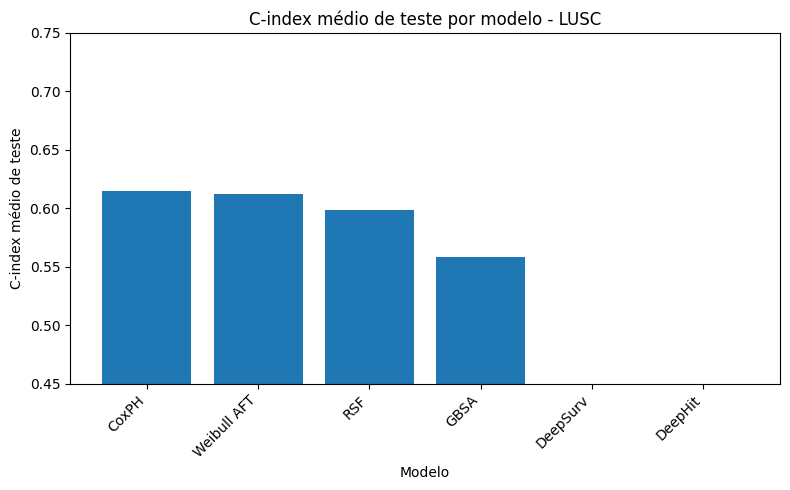

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\lusc\lusc_cindex_modelos.png


In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["c_index_teste_medio"]
)

ax.set_title("C-index médio de teste por modelo - LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index médio de teste")
ax.set_ylim(0.45, 0.75)

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "lusc_cindex_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print( figures_dir / "lusc_cindex_modelos.png")

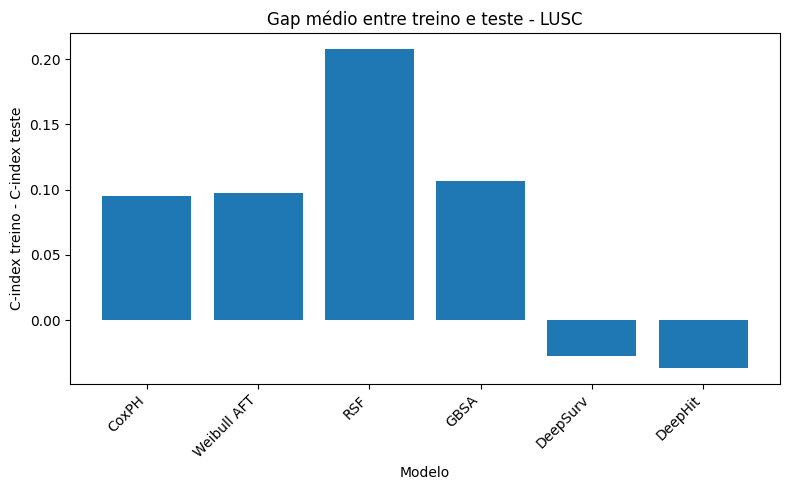

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\lusc\lusc_gap_modelos.png


In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste - LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "lusc_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "lusc_gap_modelos.png")